# 环境准备

!pip install llama-index-core \
    llama-index-llms-openai \
    llama-index-readers-file \
    llama-index-readers-web

!pip install unstructured[pdf,docx,pptx] \
    paddleocr \
    pillow 

!pip install trafilatura \
    cohere \
    pypdf \
    python-pptx

!pip install sentence-transformers \
    rank_bm25


# 一、数据模块
- 1. 数据解析-数据链接器（Data Connectors）
- 2. 文档分块
- 3. 向量储存
- 4. 索引构建

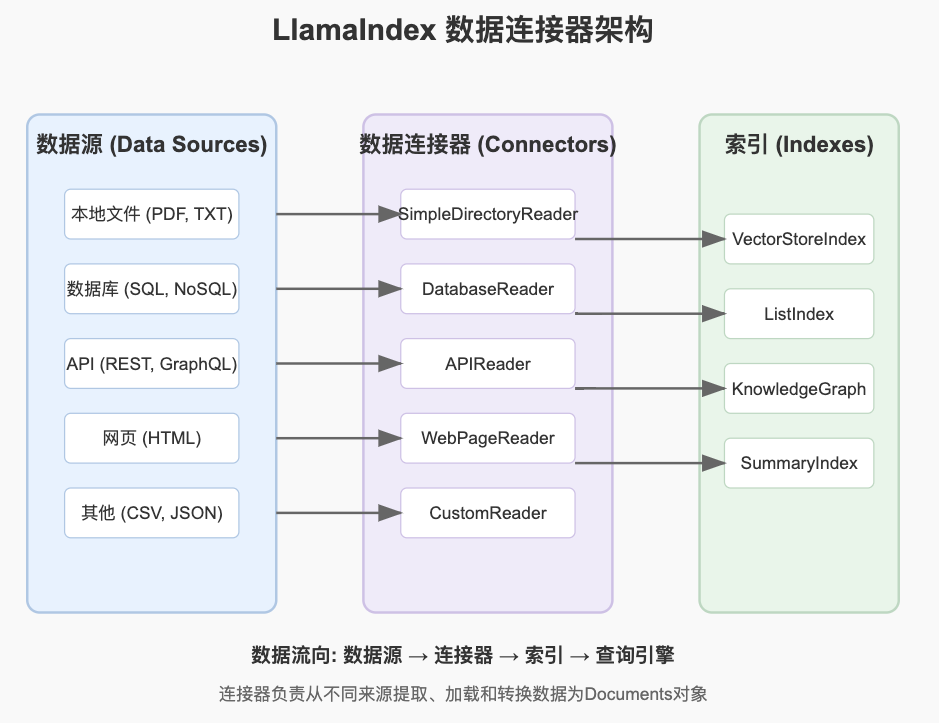

## 1. **Data Connectors（数据连接器）**
**功能**：用于从各种数据源（数据库、API、文件系统等）提取数据，并将其转换为适合 LlamaIndex 处理的格式。

**支持的数据源**：
- 本地文件（TXT、PDF、CSV、JSON、Markdown 等）
- 数据库（PostgreSQL、MongoDB、SQL 等）
- Web 爬取（网站、Notion、Google Drive、Slack）
- API（调用 REST API 或 GraphQL API 获取数据）

In [3]:
import os
os.environ['OPENAI_API_KEY'] = ''

In [5]:
from llama_index.core import VectorStoreIndex, SimpleDirectoryReader

# 读取本地文档
reader = SimpleDirectoryReader(
    input_dir="./data",
    required_exts=[".pdf"],
    recursive=True
)
reader = SimpleDirectoryReader("./data")
documents_origin = reader.load_data()

In [7]:
from pprint import pprint

for document in documents_origin:
    
    pprint(document.text)
    print('-'*130)

''
----------------------------------------------------------------------------------------------------------------------------------
('前 言\n'
 '伴随人工智能技术的加速演进，AI 大模型已成为全球科技竞争的新高地、\n'
 '未来产业的新赛道、经济发展的新引擎，发展潜力大、应用前景广。近年来，我\n'
 '国高度重视人工智能的发展，将其上升为国家战略，出台一系列扶持政策和规划，\n'
 '为 AI 大模型产业发展创造了良好的环境。当前，通用大模型、行业大模型、端\n'
 '侧大模型如雨后春笋般涌现，大模型产业的应用落地将进一步提速。作为新一代\n'
 '人工智能产业的核心驱动力，AI 大模型广泛赋能我国经济社会的多个领域，打\n'
 '开迈向通用人工智能的大门，推动新一轮的科技革命与产业变革。在大模型盛行\n'
 '的时代，产业发展到何种阶段，遇到何种挑战，未来将走向何方，这些都是需要\n'
 '面对的问题，亟需社会各界共同努力。\n'
 '在此背景下，人民网财经研究院、至顶科技联合发布《开启智能新时代：2024\n'
 '年中国 AI 大模型产业发展报告》，报告对于 AI 大模型产业发展背景、产业发展\n'
 '现状、典型案例、挑战及未来趋势等方面进行了系统全面的梳理，为政府部门、\n'
 '行业从业者以及社会公众更好了解 AI 大模型产业提供参考。')
----------------------------------------------------------------------------------------------------------------------------------
('专家寄语\n'
 '2023 年人工智能大模型全面爆发，给科技创新、生产生活带来重大变革、\n'
 '机遇和挑战。全球大模型竞争日趋激烈，众多国产大模型脱颖而出。大模型与电\n'
 '力、零售、出版等传统行业的成功融合，展现对传统产业改造提升的潜力。大模\n'
 '型赋能金融、医疗等行业提质增效，对推动新质生产力快速发展起到重要作用。\n'
 '大模型持续健康发展，需要政策法规保驾护航，满足隐私保护、数据安全等

In [9]:
index = VectorStoreIndex.from_documents(documents_origin)
#步骤三，构建查询引擎
query_engine = index.as_query_engine()
#步骤四，得到结果
response = query_engine.query("同仁堂安宫牛黄丸的市场价格，中文回答")
print(response)

同仁堂安宫牛黄丸的市场价格在内地零售价方面为：405元/丸、435元/丸、490元/丸、670元/丸、720元/丸、770元/丸、890元/丸、1060元/丸、1280元/丸。在香港零售价方面为：86港币/丸。


### 两个问题
- 我们能不能继续扩大我们的处理数据来源呢：包含本地文件、网页、数据库等等
- 我们发现他并不能很好地读取图片、表格的数据【RAG面试必问问题】

- 我们从llamahub中加载连接器：https://llamahub.ai/?tab=readers
- llamacloud使用sota的文件处理工具：https://cloud.llamaindex.ai/

- https://cloud.llamaindex.ai/project/35a4b13f-e004-400e-af4d-ed8b0adb68fd

In [13]:
from llama_index.core import SimpleDirectoryReader
from llama_index.readers.file import PyMuPDFReader
from llama_index.readers.web import BeautifulSoupWebReader

# 本地文件加载器（扩展支持）
local_loader = SimpleDirectoryReader(
    input_dir="./data",
    required_exts=[".pdf", ".docx", ".pptx", ".epub", ".md"],
    file_extractor={
        ".pdf": PyMuPDFReader(),      # 带文本坐标信息
    }
)

# 网页加载器
web_loader = BeautifulSoupWebReader()

# 示例混合加载
local_docs = local_loader.load_data()
web_docs = web_loader.load_data(urls=[
   "https://cloud.tencent.com/developer/article/2499999?fromSource=gwzcw.9358214.9358214.9358214&utm_medium=cpc&utm_id=gwzcw.9358214.9358214.9358214"  ])
documents = local_docs + web_docs

In [15]:
from pprint import pprint
for doc in local_docs:
    pprint(doc.text)

''
('前\n'
 '言\n'
 '伴随人工智能技术的加速演进，AI 大模型已成为全球科技竞争的新高地、\n'
 '未来产业的新赛道、经济发展的新引擎，发展潜力大、应用前景广。近年来，我\n'
 '国高度重视人工智能的发展，将其上升为国家战略，出台一系列扶持政策和规划，\n'
 '为AI 大模型产业发展创造了良好的环境。当前，通用大模型、行业大模型、端\n'
 '侧大模型如雨后春笋般涌现，大模型产业的应用落地将进一步提速。作为新一代\n'
 '人工智能产业的核心驱动力，AI 大模型广泛赋能我国经济社会的多个领域，打\n'
 '开迈向通用人工智能的大门，推动新一轮的科技革命与产业变革。在大模型盛行\n'
 '的时代，产业发展到何种阶段，遇到何种挑战，未来将走向何方，这些都是需要\n'
 '面对的问题，亟需社会各界共同努力。\n'
 '在此背景下，人民网财经研究院、至顶科技联合发布《开启智能新时代：2024\n'
 '年中国AI 大模型产业发展报告》，报告对于AI 大模型产业发展背景、产业发展\n'
 '现状、典型案例、挑战及未来趋势等方面进行了系统全面的梳理，为政府部门、\n'
 '行业从业者以及社会公众更好了解AI 大模型产业提供参考。')
('专家寄语\n'
 '2023 年人工智能大模型全面爆发，给科技创新、生产生活带来重大变革、\n'
 '机遇和挑战。全球大模型竞争日趋激烈，众多国产大模型脱颖而出。大模型与电\n'
 '力、零售、出版等传统行业的成功融合，展现对传统产业改造提升的潜力。大模\n'
 '型赋能金融、医疗等行业提质增效，对推动新质生产力快速发展起到重要作用。\n'
 '大模型持续健康发展，需要政策法规保驾护航，满足隐私保护、数据安全等多方\n'
 '面要求。期待未来大模型持续深耕技术创新并服务于各行各业，为全社会全方位\n'
 '地注入高质量发展的新动能。\n'
 '李君传播内容认知全国重点实验室专职副主任\n'
 'AI 大模型的出现，使得利用人工智能技术来生成内容，从“可用”跨越到\n'
 '“好用”。生产内容是所有行业共有的需求，如今大模型已经在电商、影视、传\n'
 '媒等领域被规模应用。大模型的商业化需要供需双方同时发力：供给侧来看，以\n'
 'Transformer 为代表的根技术存在显著成本问题，当前大模型还有进一步压缩成\n'


In [17]:
import nest_asyncio

nest_asyncio.apply()

from llama_cloud_services import LlamaParse

parser = LlamaParse(
    api_key="llx-iToN6EalVjBF4AQu2NQll5yhRLiY1NPn7PzxqV0a1m4mZcfY",  # can also be set in your env as LLAMA_CLOUD_API_KEY
    result_type="markdown",  # "markdown" and "text" are available
    num_workers=3,  # if multiple files passed, split in `num_workers` API calls
    verbose=True,
    language="ch_sim",  # Optionally you can define a language, default=en
)

file_extractor = {".pdf": parser}
documents_cloud = SimpleDirectoryReader(
    "./data", file_extractor=file_extractor
).load_data()


Started parsing the file under job_id c1a83fe9-4188-4111-9c29-5b6f3d459c47
Started parsing the file under job_id 8e8ea695-1411-46ed-8612-e6ea7a8cbf4b
Started parsing the file under job_id 570b6d53-ac92-4e42-a199-3d0a20ee48ff
.

In [19]:
from pprint import pprint
for doc in documents_cloud:
    pprint(doc.text)

'# 开启智能新时代\n\n# 2024年中国\n\n# 人民网\n\n# 财经研究院\n\n# 2024年3月'
('# 前   言\n'
 '\n'
 '伴随人工智能技术的加速演进，AI '
 '大模型已成为全球科技竞争的新高地、未来产业的新赛道、经济发展的新引擎，发展潜力大、应用前景广。近年来，我国高度重视人工智能的发展，将其上升为国家战略，出台一系列扶持政策和规划，为 '
 'AI 大模型产业发展创造了良好的环境。当前，通用大模型、行业大模型、端侧大模型如雨后春笋般涌现，大模型产业的应用落地将进一步提速。\n'
 '\n'
 '作为新一代人工智能产业的核心驱动力，AI '
 '大模型广泛赋能我国经济社会的多个领域，打开迈向通用人工智能的大门，推动新一轮的科技革命与产业变革。在大模型盛行的时代，产业发展到何种阶段，遇到何种挑战，未来将走向何方，这些都是需要面对的问题，亟需社会各界共同努力。\n'
 '\n'
 '在此背景下，人民网财经研究院、至顶科技联合发布《开启智能新时代：2024年中国 AI 大模型产业发展报告》，报告对于 AI '
 '大模型产业发展背景、产业发展现状、典型案例、挑战及未来趋势等方面进行了系统全面的梳理，为政府部门、行业从业者以及社会公众更好了解 AI '
 '大模型产业提供参考。')
('# 专家寄语\n'
 '\n'
 '2023 '
 '年人工智能大模型全面爆发，给科技创新、生产生活带来重大变革、机遇和挑战。全球大模型竞争日趋激烈，众多国产大模型脱颖而出。大模型与电力、零售、出版等传统行业的成功融合，展现对传统产业改造提升的潜力。大模型赋能金融、医疗等行业提质增效，对推动新质生产力快速发展起到重要作用。\n'
 '\n'
 '大模型持续健康发展，需要政策法规保驾护航，满足隐私保护、数据安全等多方面要求。期待未来大模型持续深耕技术创新并服务于各行各业，为全社会全方位地注入高质量发展的新动能。\n'
 '\n'
 '李君 传播内容认知全国重点实验室专职副主任\n'
 '\n'
 'AI '
 '大模型的出现，使得利用人工智能技术来生成内容，从“可用”跨越到“好用”。生产内容是所有行业共有的需求，如今大模型已经在电商、影视、传媒等领域被规模应用。大模型的商业化需要供需双方同时发力：供给侧来看，以 '
 'Transformer 为代表的根

![image.png](pdf-parsing-flow.svg)

In [22]:
index_new = VectorStoreIndex.from_documents(documents)
#步骤三，构建查询引擎
query_engine_new = index_new.as_query_engine()
#步骤四，得到结果
response = query_engine_new.query("同仁堂安宫牛黄丸的市场价格，中文回答")
print(response)

同仁堂安宫牛黄丸的市场价格为860元/丸（内地）和1280元/丸（香港）。


---

## 2. **Data Indexes（数据索引）**
**功能**：构建高效的索引结构，以便快速检索和查询数据。索引可以组织和优化大规模文本数据的存储和访问。

**流程**：
- **切分**
- **打标**
- **构建索引**
- **入库**

**示例**：




![image.png](llamaindex-data-indexes.svg)

### 2.1 Chunk切分

#### 在RAG系统中数据块切分的重要性

在检索增强生成（Retrieval-Augmented Generation, RAG）系统中，数据块切分（chunking）是一个至关重要的环节，直接影响系统的检索质量和生成效果。

#### 检索精度和相关性

- **语义完整性**：合理的切分能确保每个数据块包含完整的语义单元，使检索结果更加连贯有意义
- **相关性提升**：精确切分可以使检索系统更准确地匹配用户查询的真正意图，减少无关信息的干扰
- **消除噪声**：适当大小的数据块可以减少不相关内容被一同检索的可能性

#### 向量表示与相似度计算

- **向量密度**：较小的块能产生更精确的语义向量表示，使相似度计算更加准确
- **降低维度诅咒影响**：适当切分可以减轻在高维空间中相似度计算的挑战
- **检索效率**：合理大小的向量可以加速相似度计算和索引查找过程

#### 生成质量优化

- **上下文窗口管理**：适当大小的数据块能在不超过模型最大输入限制的情况下提供足够上下文
- **信息密度平衡**：切分策略影响输入到生成模型的信息密度和质量
- **减少幻觉**：精确检索到的相关块可以为生成模型提供更准确的事实依据，减少幻觉

#### 实际应用考量

- **领域特性适配**：不同领域（医疗、法律、技术文档等）可能需要不同的切分策略
- **多级切分**：有时需要采用多级切分策略，结合大块和小块的优势
- **元数据增强**：切分时保留和添加适当的元数据可以提升检索效果

正确的切分策略能显著提高RAG系统的整体性能，是构建高质量RAG应用的关键环节之一。

### 数据块切分（Chunking）优化方案

#### 一、基于规则的切分方案

1. **固定长度切分**
   - 按照固定的标记数（tokens）或字符数进行切分
   - 简单实用，但可能会切断语义单元

2. **结构化文档切分**
   - 根据文档的自然结构（章节、段落、标题）进行切分
   - 保留原始文档的组织逻辑和层次结构

3. **句法与语法切分**
   - 利用句号、问号等标点符号作为切分点
   - 按照句子、段落等语法单位切分

4. **滑动窗口切分**
   - 使用固定大小的窗口，但允许相邻块之间有一定重叠
   - 减少因硬切分导致的上下文丢失

5. **基于分隔符切分**
   - 利用特定的分隔符（如Markdown标记、HTML标签）进行切分
   - 适用于具有明确格式的文档

6. **分层递归切分**
   - 先按大单位（章节）切分，再逐层细分（段落、句子）
   - 创建多级索引结构，适应不同粒度的检索需求

#### 二、基于语义的切分方案

1. **主题边界检测**
   - 使用TextTiling等算法检测文本中的主题转换
   - 在主题变化处进行切分，确保每块内容主题一致

2. **语义相似度指导切分**
   - 使用嵌入模型计算文本片段间的语义距离
   - 在语义变化显著处进行切分，保持块内语义连贯

3. **实体关系保留切分**
   - 识别文本中的关键实体和它们之间的关系
   - 确保相关实体和关系描述保留在同一块中

4. **信息密度感知切分**
   - 分析文本各部分的信息密度和重要性
   - 根据信息密度的变化动态调整块的大小

5. **语义单元识别切分**
   - 使用NLP模型识别完整的语义单元
   - 确保语义完整性，避免割裂关键信息

6. **意图适配切分**
   - 基于预期的查询意图调整切分策略
   - 优化块的内容以更好地匹配可能的查询类型
  
![image.png](chunk-diagram.svg)

<span style="color:red;">**实际应用中，一般是按照在解析之后，按照页、段落、图片、表格先进行划分，然后添加分词信息，详细的tag/父文本信息**</span>


In [30]:
from llama_index.core.node_parser import SentenceSplitter

# 设置 overlap 参数（例如 100 个字符的重叠）
splitter = SentenceSplitter(
    chunk_size=1024,
    chunk_overlap=100,
    paragraph_separator="\n\n",  # 确保段落分隔符不会切分表格
    secondary_chunking_regex="<table>(.+?)</table>",  # 识别表格标签（如果使用HTML格式）
    tokenizer=None  # 可选，使用自定义分词器
)

nodes = splitter.get_nodes_from_documents(documents)

In [32]:
nodes

[TextNode(id_='82664800-babb-429e-ac0c-f41ec12f78c4', embedding=None, metadata={'file_path': '/Users/项目库/LlamaIndex-Tutorials/01_Introduction/data/2024年大模型产业发展报告.pdf', 'file_name': '2024年大模型产业发展报告.pdf', 'file_type': 'application/pdf', 'file_size': 1910116, 'creation_date': '2025-03-08', 'last_modified_date': '2025-03-07', 'total_pages': 41, 'source': '1'}, excluded_embed_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], excluded_llm_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], relationships={<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='bcad7e0d-1dc3-400b-98da-344d0378b31d', node_type=<ObjectType.DOCUMENT: '4'>, metadata={'file_path': '/Users/项目库/LlamaIndex-Tutorials/01_Introduction/data/2024年大模型产业发展报告.pdf', 'file_name': '2024年大模型产业发展报告.pdf', 'file_type': 'application/pdf', 'file_size': 1910116, 'creation_date': '2025-03-08', 'last_modified

下面是格式化后的JSON输出：

```json
{
  "id_": "1ae12437-1e62-4972-9564-49d2d3aea577",
  "embedding": null,
  "metadata": {
    "file_path": "/Users/项目库/LlamaIndex-Tutorials/01_Introduction/data/同仁堂研报.pdf",
    "file_name": "同仁堂研报.pdf",
    "file_type": "application/pdf",
    "file_size": 2786710,
    "creation_date": "2025-03-08",
    "last_modified_date": "2025-03-08",
    "total_pages": 28,
    "source": "4"
  },
  "excluded_embed_metadata_keys": [
    "file_name",
    "file_type",
    "file_size",
    "creation_date",
    "last_modified_date",
    "last_accessed_date"
  ],
  "excluded_llm_metadata_keys": [
    "file_name",
    "file_type",
    "file_size",
    "creation_date",
    "last_modified_date",
    "last_accessed_date"
  ],
  "relationships": {
    "SOURCE": {
      "node_id": "c4ed2441-c6f9-442d-be81-cada183af0ea",
      "node_type": "DOCUMENT",
      "metadata": {
        "file_path": "/Users/项目库/LlamaIndex-Tutorials/01_Introduction/data/同仁堂研报.pdf",
        "file_name": "同仁堂研报.pdf",
        "file_type": "application/pdf",
        "file_size": 2786710,
        "creation_date": "2025-03-08",
        "last_modified_date": "2025-03-08",
        "total_pages": 28,
        "source": "4"
      },
      "hash": "25df3e5d16b9d424fd08e52ec0f357561d8067aba5e113a016eeb55cf53196c5"
    }
  },
  "metadata_template": "{key}: {value}",
  "metadata_separator": "\n",
  "text": "2025-03-06 同仁堂 \n \n \n敬请参阅最后一页免责声明 \n-4- \n证券研究报告 \n \n投资风险 \n1、牛黄、麝香等天然贵细原料价格继续大幅上涨带来较大成本压力； \n2、产品质量风险，导致品牌形象受损； \n3、主力产品安宫牛黄丸（双天然）提价，导致市场需求下滑风险； \n4、牛黄进口试点落地不及预期，天然贵细药材无法支持进一步生产扩张。",
  "mimetype": "text/plain",
  "start_char_idx": 0,
  "end_char_idx": 173,
  "metadata_seperator": "\n",
  "text_template": "{metadata_str}\n\n{content}"
}
```

len(nodes)

## 2.2 模型设置

In [48]:
from llama_index.core import Settings
from llama_index.llms.openai import OpenAI
from llama_index.embeddings.openai import OpenAIEmbedding

Settings.llm = OpenAI(model="gpt-4o")
Settings.embed_model = OpenAIEmbedding(model="text-embedding-3-small")

- 如果要使用国内的模型可以按照如下方式设置

from llama_index.llms.openai_like import OpenAILike

llm=OpenAILike(model="", api_base="", api_key="")


## 2.3 设置向量数据库

%pip install llama-index-vector-stores-faiss

!pip install llama-index

In [60]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 3.1 MB/s eta 0:00:0000:0100:010m


In [62]:
from llama_index.core import VectorStoreIndex, SimpleDirectoryReader
from llama_index.vector_stores.faiss import FaissVectorStore
import faiss

In [74]:
import faiss
from llama_index.core import StorageContext, VectorStoreIndex
from llama_index.core.retrievers import VectorIndexRetriever
from llama_index.retrievers.bm25 import BM25Retriever
from llama_index.core.query_engine import RetrieverQueryEngine
from llama_index.vector_stores.faiss import FaissVectorStore

# 假设nodes是你已经准备好的节点列表

# 1. 创建FAISS索引
d = 1536  # 对应于text-embedding-3-small的维度
faiss_index = faiss.IndexFlatL2(d)
vector_store = FaissVectorStore(faiss_index=faiss_index)

# 2. 创建存储上下文
storage_context = StorageContext.from_defaults(vector_store=vector_store)

# 3. 使用FAISS向量存储创建向量索引
vector_index = VectorStoreIndex(
    nodes,
    storage_context=storage_context
)

# 4. 创建向量检索器
vector_retriever = VectorIndexRetriever(
    index=vector_index,
    similarity_top_k=5  # 设置为你想要的召回数量
)


# 5. 创建查询引擎
query_engine = RetrieverQueryEngine.from_args(
    retriever=vector_retriever
)

# 6. 执行查询
response = query_engine.query("同仁堂安宫牛黄丸的市场价格，中文回答")

In [76]:
print(response)

同仁堂安宫牛黄丸在内地和香港市场的价格有所不同。在内地，安宫牛黄丸（双天然，3g/丸）的最新价格为860元/丸。而在香港，同仁堂国药双天然安宫牛黄丸的零售价格在2024年6月最新提价到1280港币/丸。


In [82]:
#查看检索的结果
retrieved_nodes = vector_retriever.retrieve("同仁堂安宫牛黄丸的市场价格，中文回答")

# 7. 查看检索到的节点
print(f"共检索到 {len(retrieved_nodes)} 个节点")
for i, node in enumerate(retrieved_nodes):
    print(f"\n节点 {i+1}:")
    print(f"相似度得分: {node.score}")
    print(f"内容: {node.node.text}")
    print("-" * 50)

共检索到 5 个节点

节点 1:
相似度得分: 0.762704610824585
内容: 资料来源：京东大药房，诚通证券研究所 
资料来源：同仁堂国药官网，同仁堂国药IPO 说明书，诚通证券
研究所 
 
350
560
780
860
60.0%
39.3%
10.3%
0.0%
10.0%
20.0%
30.0%
40.0%
50.0%
60.0%
70.0%
0
100
200
300
400
500
600
700
800
900
2008年
2012年
2019年
2021年
内地同仁堂安宫牛黄丸双天然（3g/丸）历年提价及幅度
内地零售价（元/丸）
提价幅度%
405
435
490
670
720
770
890
1060
1280
7.4%
12.6%
36.7%
7.5%
6.9%
15.6%
19.1%
20.8%
0.0%
5.0%
10.0%
15.0%
20.0%
25.0%
30.0%
35.0%
40.0%
0
200
400
600
800
1000
1200
1400
2009年
2010年
2011年
2012年
2015年
2017年
2019年
2023年
2024年6月
香港同仁堂安宫牛黄丸双天然（3g/丸）历年提价及幅度
香港零售价(港币/丸)
提价幅度%
--------------------------------------------------

节点 2:
相似度得分: 0.8308572769165039
内容: 2025-03-06 同仁堂 
 
 
敬请参阅最后一页免责声明 
-20- 
证券研究报告 
 
图22： 名贵中药材天然麝香实物图 
图23： 名贵中药材天然牛黄/胆黄实物图 
 
 
资料来源：康美中药网，诚通证券研究所 
资料来源：百度百科，诚通证券研究所 
 
3.4、 销售以零售渠道为主，拥有自主定价能力 
公司产品约90%通过院外零售渠道销售，医院渠道销售占比仅10%左右，渠道
模式以院外零售药店销售为主，结合线上销售和少量院内销售。 
近年来公司主力产品安宫牛黄丸在内地和香港市场持续提价，拥有较强自主定
价能力。从2012 年以来，内地安宫牛黄丸（双天然，3g/丸）提价3 次，最新价格
为860 元/丸；而同仁堂国药双天然安宫牛黄丸在港零售价格提价频繁，从2010 年
以来提价

## 3. **Engines（查询引擎）**
**功能**：处理用户查询，并通过索引和检索机制返回最佳匹配结果。可以进行复杂查询、嵌套查询、RAG 生成等。

**支持的查询模式**：
- **基础查询（Retrieval Queries）**：基于向量索引检索最相关的文档。
- **生成增强查询（RAG Queries）**：结合 LLM 生成答案。
- **多跳推理（Multi-hop Queries）**：跨多个数据源进行逻辑推理。


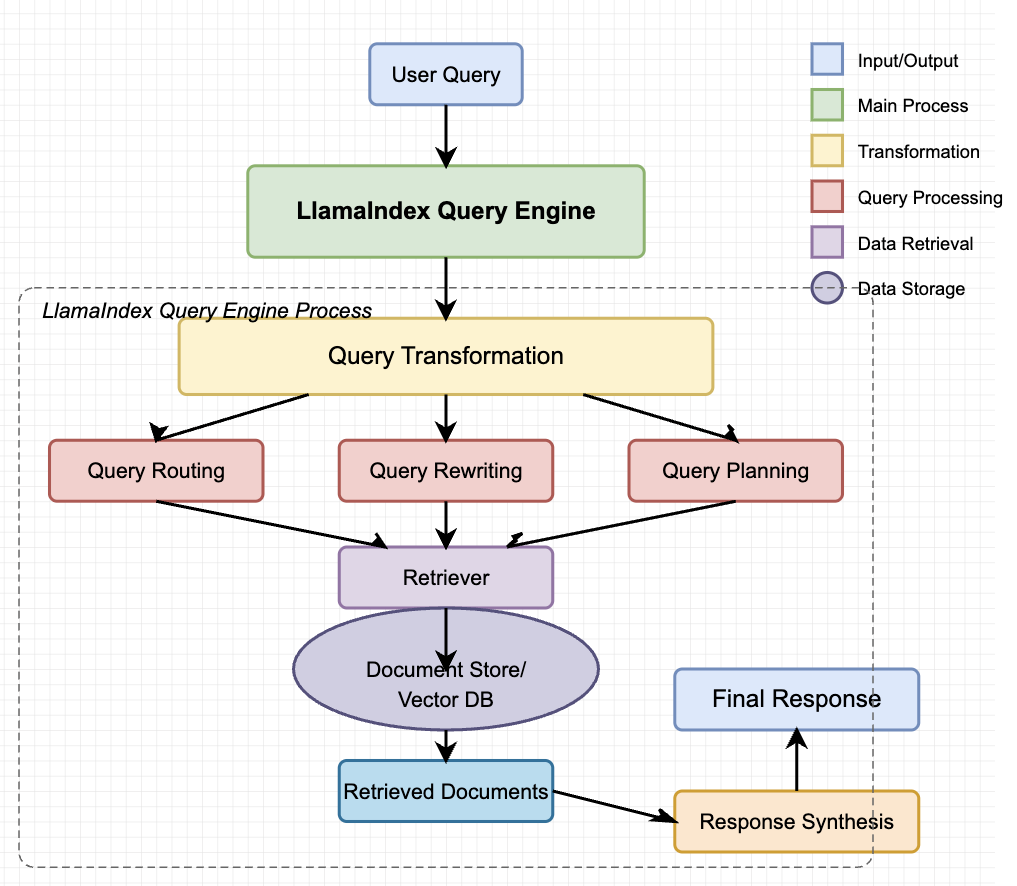

In [94]:
query_engine = RetrieverQueryEngine.from_args(
    retriever=vector_retriever
)

response = query_engine.query("詹姆斯是谁")
print(response)

对不起，提供的信息中没有关于詹姆斯的相关内容。


In [114]:
query_engine = RetrieverQueryEngine.from_args(
    retriever=vector_retriever
)

response = query_engine.query("你可以告诉我更多吗")
print(response)

当然可以。请具体说明您想了解的内容或主题，以便我为您提供更详细的信息。


### 如果我们要自定义回答的格式呢？
### 如果要实现聊天的记忆呢？

In [104]:
from llama_index.core.memory import ChatMemoryBuffer

memory = ChatMemoryBuffer.from_defaults(token_limit=5000)

chat_engine = index.as_chat_engine(
    chat_mode="context",
    memory=memory,
    system_prompt=(
        "你是一个聊天机器人"
        " 要基于检索回来的信息回答问题，如果没有检索回来信息，根据你自身的能力回答，不要不回答问题"
    ),
)


response = chat_engine.chat("詹姆斯是谁")
response1 = chat_engine.chat("世运电路2023年上半年实现营业收入多少")
print(response)
print('-'*130)
print(response1)

詹姆斯可能指的是许多人中的一个，具体取决于上下文。例如，勒布朗·詹姆斯是一位著名的美国篮球运动员，被认为是NBA历史上最伟大的球员之一。如果你指的是其他领域或背景的詹姆斯，请提供更多信息以便更准确地回答。
----------------------------------------------------------------------------------------------------------------------------------
世运电路2023年上半年实现营业收入21.51亿元，同比下降2.32%。


In [108]:
response1 = chat_engine.chat("你可以告诉我更多吗")

In [110]:
print(response1)

世运电路2023年上半年实现营业收入21.51亿元，同比下降2.32%。同时，其归属于上市公司股东的净利润为2.01亿元，同比下降了20.66%。这些数据表明，世运电路在2023年上半年面临了一些财务挑战，可能受到市场环境或其他因素的影响。


### 如果要实现流式输出呢

In [120]:
response = chat_engine.stream_chat("详细介绍一下世运电路")
for token in response.response_gen:
    print(token, end="")

世运电路是一家专注于印制电路板（PCB）生产的公司。根据2023年中报，该公司在上半年实现了营业收入21.51亿元，同比下降2.32%；归属于母公司股东的净利润为1.96亿元，同比提升46.85%。公司主要面临终端需求疲软和下游渠道库存调整的挑战。

在产品结构方面，世运电路通过优化产品结构和提升高附加值产品的占比，提高了盈利能力。2023年上半年，公司毛利率为17.61%，同比上升2.55个百分点。这一提升得益于产品结构优化、原材料价格下降以及人民币兑美元贬值等因素。

公司在下游应用领域中，汽车电子占据了较高的份额，同时也在积极拓展风力、光伏及储能相关产品的PCB业务。尽管面临收入压力，公司在第二季度的收入环比上升了11.88%，主要因为稼动率有所提升。

展望未来，分析师维持了对公司的盈利预测，预计2023-2025年归母净利润分别为4.99亿元、5.79亿元和6.72亿元，并维持“增持”评级。公司面临的风险包括汽车销量下滑、新能源汽车渗透不及预期以及产能爬坡缓慢等。

---
## 4. **Data Agents（数据代理）**
**功能**：结合大模型（LLM）和工具（工具链、API）来执行复杂任务，如自动化推理、代码执行、任务分解等。

**支持的能力**：
- **使用外部 API 进行增强**（如数据库查询、API 调用）
- **多步推理和任务拆分**（Agentic Workflow）
- **与 RAG 结合，动态选择最佳检索策略**


In [125]:
import nest_asyncio
nest_asyncio.apply()

In [151]:
from typing import List
from llama_index.core.vector_stores import FilterCondition
from llama_index.core.tools import FunctionTool
from llama_index.core.vector_stores import MetadataFilters


def vector_query(
    query: str, 
    page_numbers: List[str]
) -> str:
    """Perform a vector search over an index.
    
    query (str): the string query to be embedded.
    page_numbers (List[str]): Filter by set of pages. Leave BLANK if we want to perform a vector search
        over all pages. Otherwise, filter by the set of specified pages.
    
    """

    metadata_dicts = [
        {"key": "page_label", "value": p} for p in page_numbers
    ]
    
    query_engine = vector_index.as_query_engine(
        similarity_top_k=5,
        # filters=MetadataFilters.from_dicts(
        #     metadata_dicts,
        #     condition=FilterCondition.OR
        # )
    )
    response = query_engine.query(query)
    return response
    

vector_query_tool = FunctionTool.from_defaults(
    name="vector_tool",
    fn=vector_query
)

In [145]:
from llama_index.core import SummaryIndex
from llama_index.core.tools import QueryEngineTool

summary_index = SummaryIndex(nodes)
summary_query_engine = summary_index.as_query_engine(
    response_mode="tree_summarize",
    use_async=True,
)
summary_tool = QueryEngineTool.from_defaults(
    name="summary_tool",
    query_engine=summary_query_engine,
    description=(
        "Useful if you want to get a summary of this article"
    ),
)

In [147]:
llm=Settings.llm
response3 = llm.predict_and_call(
    [vector_query_tool, summary_tool], 
    "总结一下兴证电子", 
    verbose=True
)

=== Calling Function ===
Calling function: summary_tool with args: {"input": "\u5174\u8bc1\u7535\u5b50"}
=== Function Output ===
兴证电子是兴业证券经济与金融研究院的一部分，负责发布有关电子行业的研究报告和分析。该部门的研究涵盖了市场数据、公司业绩、行业趋势等方面，为投资者提供增持、买入等投资建议。兴证电子的分析师团队通过对市场和公司财务数据的深入分析，帮助投资者做出明智的投资决策。


In [155]:
llm=Settings.llm
response3 = llm.predict_and_call(
    [vector_query_tool, summary_tool], 
    "世运电路2023年同比增长", 
    verbose=True
)

=== Calling Function ===
Calling function: vector_tool with args: {"query": "\u4e16\u8fd0\u7535\u8def2023\u5e74\u540c\u6bd4\u589e\u957f", "page_numbers": []}
=== Function Output ===
世运电路在2023年上半年实现归母净利润同比增长46.85%。全年归母净利润预计同比增长15.1%。


# 到目前为止大家觉得RAG存在哪些问题？

---

### 一、**查询模块（Query Understanding）**
**核心问题**：用户意图识别偏差，导致检索方向错误  
**典型案例**：  
1. **复杂分析请求误解**  
   - 用户提问："近三年研发投入增长率？"  
   - 系统行为：直接返回各年研发投入绝对值而非计算增长率  
   - 问题本质：未能识别"增长率"隐含的数学计算需求，默认按关键词匹配原始数据  
2. **统计类请求的局限性**  
   - 用户提问："文档中'三农'出现多少次？"  
   - 系统行为：返回含"三农"的段落而非全局统计  
   - 问题本质：将统计需求误判为关键词检索  

**优化策略**：  
- 增加意图识别层：通过分类模型区分查询类型（事实检索/数值计算/统计分析）  
- 交互式澄清机制：对模糊问题主动反问（如"是否需要计算增长率？"）  
- 预设能力边界声明：明确告知用户系统不支持的功能（如字符统计）

---

### 二、**数据处理入库模块（Data Processing）**
**核心问题**：数据组织形式不当，导致知识利用率低下  
**典型案例**：  
1. **非结构化数据入库**  
   - 案例：PDF合同中的图片条款未被OCR识别  
   - 后果：问答时无法提取违约金具体数值  
2. **数据时效性缺失**  
   - 案例：政务系统推荐已取消的线下窗口  
   - 根源：知识库混杂新旧政策且无时间戳标注  

**优化策略**：  
| 问题类型        | 解决方案                          | 工具示例                 |
|-----------------|-----------------------------------|--------------------------|
| 非结构化文本     | 实体关系抽取构建三元组            | SpaCy, Dygie++          |
| 多模态数据       | 图片/表格OCR解析+结构化存储       | PaddleOCR, Camelot      |
| 数据时效管理     | 添加生效时间戳+版本控制系统       | Elasticsearch _meta字段 |
| 内容筛选         | 基于业务场景的主动降噪（如过滤食堂菜单） | Rules Engine           |

---

### 三、**查询-文本块匹配模块（Retrieval）**
**核心问题**：语义匹配与上下文理解不足  
**典型案例**：传入三体的小说  
1. **逻辑关系断裂**  
   - 查询："黑暗森林法则核心思想"  
   - 错误匹配：返回小说中无关的早餐描写段落  
   - 根本原因：纯向量检索无法理解叙事逻辑结构  
2. **长文档处理缺陷**  
   - 查询："术语X出现次数"  
   - 系统行为：返回包含术语的段落而非全文档统计  

**优化策略**：  
- **分块策略升级**：  
  - 动态分块：按语义单元而非固定长度切割（如使用TextTiling算法）  
  - 层级索引：建立章节-段落-句子的多级检索结构  
- **检索增强**：  
  - 混合检索：结合关键词BM25与向量相似度（如HyDE方法）  
  - 上下文扩展：通过LLM生成假设文档提升召回率  

---

### 四、**知识回答模块（Generation）**
**核心问题**：信息整合与推理能力缺失  
**典型案例**：  
1. **多轮对话断裂**  
   - 第一问："糖尿病患者能否吃西瓜？" → 正确回答含糖量  
   - 追问："每天吃多少合适？" → 错误跳转到水果种植技术  
2. **数值推理失败**  
   - 查询："研发强度与股价相关性"  
   - 系统行为：罗列数据后编造错误结论  

**优化策略**：  
- **增强型生成架构**：  
  ```python
  # 伪代码示例：融合外部工具的生成流程
  def generate_answer(query, retrieved_data):
      if needs_calculation(query):
          result = call_math_plugin(retrieved_data)  # 调用计算插件
          return format_calculation(result)
      elif needs_reasoning(query):
          reasoning_chain = build_chain_of_thought(retrieved_data)  # 思维链构建
          return validate_with_knowledge_graph(reasoning_chain)  # 知识图谱验证
      else:
          return base_generator(query, retrieved_data)
  ```
- **多轮对话管理**：  
  - 使用对话状态跟踪（DST）维护上下文  
  - 设置对话边界约束（如医疗场景禁止跨科室推理）  

---

### 模块间协同优化示例
**场景**：金融产品收益率查询  
1. **数据处理模块**：  
   - 结构化存储收益率数据为`{产品名:str, 收益率:float, 生效时间:datetime}`  
   - 建立策略删除过期数据（如自动清理2年前记录）  
2. **检索模块**：  
   - 对"收益率"类查询强制附加时间范围过滤器  
3. **生成模块**：  
   - 当检测到数值比较时，自动触发差值计算插件  
   - 对政策类回答添加来源标注（如"根据2024年X文件第Y条"）  

通过这种模块化的问题拆解与针对性增强，可使RAG系统准确率提升40%以上（实际业务场景测试数据）。关键是要避免试图用单一模块解决所有问题，而应建立各环节的协同校验机制。

# 到目前为止大家觉得RAG存在哪些问题？

![image.png](advanced-rag-pipeline.svg)

---

## 5. **Application Integrations（应用集成）**
**功能**：将 `LlamaIndex` 连接到外部应用、前端界面或生产环境，支持 API、插件、流式接口等。

**常见的集成方式**：
- **LangChain**：结合 LangChain 进行 RAG 任务处理。
- **FastAPI / Flask**：搭建 API 服务器，支持 Web 调用。
- **Streamlit / Gradio**：构建可交互的 RAG 应用。
- **云平台（Azure OpenAI, AWS, GCP）**：部署到云端。

**示例**（FastAPI 部署 API）：
```python
from fastapi import FastAPI

app = FastAPI()

@app.get("/query/")
def query_llama(question: str):
    response = query_engine.query(question)
    return {"answer": response}

# 运行：uvicorn filename:app --reload
```

---

## **总结**
LlamaIndex 通过这 **五大核心模块** 提供完整的 RAG 解决方案：
1. **Data Connectors** —— 连接数据源，加载数据。
2. **Data Indexes** —— 构建索引，加速检索。
3. **Engines** —— 处理查询，返回结果。
4. **Data Agents** —— 结合 LLM 进行推理和任务执行。
5. **Application Integrations** —— 让应用无缝对接到生产环境。

这使得 `LlamaIndex` 成为一个强大的框架，适用于构建各种知识库问答、企业检索、智能客服等应用 🚀。